In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math as py_math
from datetime import date
from phi.flow import * 
from kan import KAN


# simple MLP architecture, using tanh activation for differentiability w.r.t to the inputs (need to differentiate twice)
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)
    
model_pinn = PINN()
model_uninformed = PINN()

## Gathering data for the supervised part of training

we obtain data by considering a grid of pre-defined size as well as pre-defined boundary conditions and parameters of the PDE. To obtain the velocity vector (the network target) we use phi-flow and run a simulation on this grid. The custom dataloader gathers the points, separating them into input and output tensors and performing a train-test-split to avoid data leakage. 

In [4]:
DATA_PATH = 'Data/burgers_data.npy'


def run_simulation(resolution=128, save_path=DATA_PATH):
    # 1. Setup Physical Parameters
    NU_TRUE = 0.01 / py_math.pi 
    DT = 0.01
    STEPS = 100
    
    # --- CORRECTION HERE ---
    # We do not create a 'Domain' object. 
    # We define the bounds and resolution as variables to pass later.
    BOUNDS = Box(x=(-1, 1))
    RESOLUTION = resolution
    
    # 2. Initial Condition: u(x,0) = -sin(pi * x)
    # We pass x=128 (resolution) and bounds directly here.
    initial_state = CenteredGrid(
        values=lambda x: -math.sin(py_math.pi * x), 
        extrapolation=extrapolation.PERIODIC, 
        x=RESOLUTION,      # Define Resolution here
        bounds=BOUNDS      # Define Physical Bounds here
    )

    # 3. Simulation Loop
    u_history = [initial_state.values.numpy('x')]
    t_history = [0.0]
    
    u_current = initial_state
    
    print(f"Running PhiFlow Simulation (nu={NU_TRUE:.4f})...")
    
    for i in range(1, STEPS + 1):
        # Burgers Step
        u_adv = advect.mac_cormack(u_current, u_current, dt=DT)
        u_next = diffuse.explicit(u_adv, NU_TRUE, dt=DT)
        
        u_current = u_next
        
        # Store state
        u_history.append(u_current.values.numpy('x'))
        t_history.append(i * DT)

    # 4. Data Post-Processing (Same as before)
    # Get physical x coordinates from the grid
    x_coords = initial_state.points.vector[0].numpy('x') 
    
    t_array = np.array(t_history)
    u_array = np.array(u_history) 
    
    X_grid, T_grid = np.meshgrid(x_coords, t_array)
    
    data_dict = {
        "x": X_grid.flatten()[:, None].astype(np.float32),
        "t": T_grid.flatten()[:, None].astype(np.float32),
        "u": u_array.flatten()[:, None].astype(np.float32)
    }
    
    print(f"Simulation Complete. Data shape: {data_dict['x'].shape}")
    np.save(save_path, data_dict, allow_pickle=True)

    return data_dict

def prepare_data(file_path=DATA_PATH, t_split=0.5, spatial_mask_ratio=0.8):
    """
    Loads data and performs strict spatio-temporal splitting to prevent leakage.
    - Temporal Extrapolation: Train on t <= t_split, Test on t > t_split.
    - Spatial Interpolation: Randomly mask a percentage of spatial points in the training set.
    """
    data = np.load(file_path, allow_pickle=True).item()
    x_all = data['x']
    t_all = data['t']
    u_all = data['u']
    
    # A. Temporal Split (Forecasting Validation)
    train_time_mask = (t_all <= t_split).flatten()
    test_time_mask = (t_all > t_split).flatten()
    
    x_train_temp = x_all[train_time_mask]
    t_train_temp = t_all[train_time_mask]
    u_train_temp = u_all[train_time_mask]
    
    x_test = x_all[test_time_mask]
    t_test = t_all[test_time_mask]
    u_test = u_all[test_time_mask]

    # B. Spatial Split (Interpolation Validation within the training time window)
    num_train_points = len(x_train_temp)
    indices = np.arange(num_train_points)
    np.random.shuffle(indices)
    
    keep_len = int(num_train_points * spatial_mask_ratio)
    train_indices = indices[:keep_len]
    
    x_train = x_train_temp[train_indices]
    t_train = t_train_temp[train_indices]
    u_train = u_train_temp[train_indices]
    
    # C. Unsupervised Collocation Points (For PDE Loss)
    # We sample points continuously across the ENTIRE domain to enforce physics everywhere
    n_colloc = 10000
    x_colloc = np.random.uniform(-1, 1, (n_colloc, 1))
    t_colloc = np.random.uniform(0, 1, (n_colloc, 1))

    # Convert everything to PyTorch tensors
    to_tensor = lambda arr: torch.tensor(arr, dtype=torch.float32)
    
    return {
        'train': (to_tensor(x_train), to_tensor(t_train), to_tensor(u_train)),
        'test': (to_tensor(x_test), to_tensor(t_test), to_tensor(u_test)),
        'colloc': (to_tensor(x_colloc), to_tensor(t_colloc))
    }

resolution = 256
t_split = 0.8
run_simulation(resolution=resolution, save_path=DATA_PATH)
prepare_data(t_split=t_split)

Running PhiFlow Simulation (nu=0.0032)...


/var/folders/0p/3b6s1cyd2glf9kj66m2vt2gm0000gn/T/ipykernel_3960/1674305724.py:36: RuntimeWarning: CFL condition violated (CFL = 0.5 > 0.5) in diffuse.explicit() with diffusivity=0.003183098861837907, dt=0.01, dx=(x=0.008) float64. Increase substeps or use diffuse.implicit() instead.
  u_next = diffuse.explicit(u_adv, NU_TRUE, dt=DT)


Simulation Complete. Data shape: (25856, 1)


{'train': (tensor([[ 0.4414],
          [ 0.6211],
          [-0.7227],
          ...,
          [-0.2070],
          [-0.5352],
          [ 0.1758]]),
  tensor([[0.1300],
          [0.3100],
          [0.7700],
          ...,
          [0.8000],
          [0.4000],
          [0.7300]]),
  tensor([[-0.9733],
          [-0.5789],
          [ 0.2521],
          ...,
          [ 0.6838],
          [ 0.6203],
          [-0.7499]])),
 'test': (tensor([[-0.9961],
          [-0.9883],
          [-0.9805],
          ...,
          [ 0.9805],
          [ 0.9883],
          [ 0.9961]]),
  tensor([[0.8100],
          [0.8100],
          [0.8100],
          ...,
          [1.0000],
          [1.0000],
          [1.0000]]),
  tensor([[ 0.0034],
          [ 0.0103],
          [ 0.0172],
          ...,
          [-0.0147],
          [-0.0088],
          [-0.0029]])),
 'colloc': (tensor([[-0.4520],
          [-0.5273],
          [ 0.2565],
          ...,
          [ 0.2559],
          [ 0.1058],
     

## Physical Loss

compute the physical loss terms through the PDE Residual and leveraging automatic differentiation to obtain gradients with respect to the input

In [5]:
def compute_physics_loss(model, x, t, nu):
    """
    Evaluates the Burgers' equation residual: u_t + u*u_x - nu*u_xx = 0
    """
    # Enable gradient tracking for the input coordinates
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    u = model(x, t)
    
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    # Define the residual
    residual = u_t + u * u_x - nu * u_xx
    
    return torch.mean(residual**2)

## Network Training

Here we consider 2 Neural Networks which have identical architecture. We will consider one of the networks as the Physics-Informed model, meaning its loss will consider both the supervised and physical loss terms simultaneously, each of them weighted. The other network will be the 'uninformed' version; because we compute both losses separetely, this enables us to consider only the supervised loss for this network's optimization process.

In [ ]:
def train_pinn(epochs, lr, informed_model, uninformed_model, lambda_0=1., lambda_1=1., t_split = 0.5, spatial_mask_ratio = 0.8):
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu"))
    informed_model.to(device)
    uninformed_model.to(device)
    print(f"Training on: {device}")
    
    # Load and split data
    nu_true = 0.01 / py_math.pi
    data_splits = prepare_data(t_split=t_split, spatial_mask_ratio=spatial_mask_ratio)
    
    x_train, t_train, u_train = [t.to(device) for t in data_splits['train']]
    x_colloc, t_colloc = [t.to(device) for t in data_splits['colloc']]

    optimizer_inf = optim.Adam(informed_model.parameters(), lr=lr)
    optimizer_uninf = optim.Adam(uninformed_model.parameters(), lr=lr)
    
    history = {'data_loss': [], 'data_loss_uninformed': [], 'pde_loss': []}

    print("Starting physics-informed optimization...")
    informed_model.train()
    uninformed_model.train()
    
    for epoch in range(epochs):

        # zero out the optimizer gradients
        optimizer_inf.zero_grad()
        optimizer_uninf.zero_grad()
        
        # compute the supervised data loss
        u_pred_informed = informed_model(x_train, t_train)
        u_pred_uninformed = uninformed_model(x_train, t_train)

        loss_data_informed = torch.nn.functional.mse_loss(u_pred_informed, u_train)
        loss_data_uninformed = torch.nn.functional.mse_loss(u_pred_uninformed, u_train)
        
        # compute the physical loss (only relevant for the informed model)
        loss_pde = compute_physics_loss(informed_model, x_colloc, t_colloc, nu=nu_true)
        
        # only for the informed network
        loss_total = lambda_0*loss_data_informed + lambda_1*loss_pde
        
        loss_total.backward()
        optimizer_inf.step()

        loss_data_uninformed.backward()
        optimizer_uninf.step()
        
        history['data_loss'].append(loss_data_informed.item())
        history['pde_loss'].append(loss_pde.item())
        history['data_loss_uninformed'].append(loss_data_uninformed.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Informed Data Loss: {loss_data_informed.item():.6e} | PDE Loss: {loss_pde.item():.6e} | Uninformed Data Loss: {loss_data_uninformed.item():.6e}")


    print("Training Complete.")
    torch.save(model_pinn.state_dict(), "Models/pinn_model_weights_run_"+str(date.today()))
    torch.save(model_uninformed.state_dict(), "Models/standard_model_weights_run_"+str(date.today()))
    return model_pinn, model_uninformed, history

def tuning(steps):

    pass
    lambda_space = np.linspace(0.1, 1, 10)
    for step in steps:
        # get random lambda0 and lambda1 points for hyperparameter tuning
        trained_model_pinn, trained_model_uninformed, splits, computation_device, history = train_pinn(epochs=10000, lr=1e-3, informed_model=model_pinn, uninformed_model=model_uninformed)


## Network Evaluation and Visualization


Test the network's extrapolation capabilities by visualizing the predicted velocity values at a given timestep selected outside the time domain used for training. 

In [20]:
# define the network class again in order to load weights
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)
    
    
def evaluate_model(model_pinn, model_uninformed, test_grid_size, history):
    
    # plot training history

    plt.figure()
    plt.plot(np.arange(len(history['data_loss'])), history['data_loss'], label = 'Supervised Loss PINN', color = 'blue')
    plt.plot(np.arange(len(history['pde_loss'])), history['pde_loss'], label = 'PDE Residual Loss', color = 'red')
    #plt.plot(np.arange(len(history['data_loss_uninformed'])), history['data_loss_uninformed'], label = 'Supervised Loss NN', color = 'green')
    plt.legend(loc = 'upper left')
    plt.title('Supervised Loss History')
    plt.ylabel('Loss Values Log Scale')
    plt.xlabel('Training Epochs')
    plt.yscale('log')
    
    plt.show()

    
    model_pinn.eval()
    model_uninformed.eval()
    
    
    # visual validation at "snapshot" t = 0.8, repeated for each network
    t_eval = 0.8
    device = torch.device("mps")
    test_x_vis = torch.linspace(-1, 1, test_grid_size).view(-1, 1).to(device)
    test_t_vis = torch.full((test_grid_size, 1), t_eval).to(device)
    
    with torch.no_grad():
        pred_vis = model_pinn(test_x_vis, test_t_vis).cpu().numpy()
        
    plt.figure(figsize=(10, 5))
    plt.plot(test_x_vis.cpu().numpy(), pred_vis, label=f"PINN Forecast (t={t_eval})", color="red")
    plt.title(f"PINN Model Extrapolation Validation at t={t_eval}")
    plt.xlabel("Spatial Coordinate (x)")
    plt.ylabel("Velocity (u)")
    plt.legend()
    plt.grid(True)
    plt.show()

    
    with torch.no_grad():
        pred_vis = model_uninformed(test_x_vis, test_t_vis).cpu().numpy()
        
    plt.figure(figsize=(10, 5))
    plt.plot(test_x_vis.cpu().numpy(), pred_vis, label=f"NN Forecast (t={t_eval})", color="blue")
    plt.title(f"Uninformed Model Extrapolation Validation at t={t_eval}")
    plt.xlabel("Spatial Coordinate (x)")
    plt.ylabel("Velocity (u)")
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(trained_model_pinn_path, trained_model_path, device, extrapolation_horizon = 0.5, file_path="burgers_data.npy"):

    model_pinn = PINN()
    model_uninformed = PINN()
    model_pinn.to(device)
    model_uninformed.to(device)


    model_pinn.load_state_dict(torch.load(trained_model_pinn_path))
    model_uninformed.load_state_dict(torch.load(trained_model_path))
   
    # original data serves as ground truth for comparison
    data = np.load(file_path, allow_pickle=True).item()
    x_flat = data['x']
    t_flat = data['t']
    u_exact_flat = data['u']
    
    # Reconstruct the 2D grid dimensions assuming a square/rectangular mesh
    # (Assuming RESOLUTION=128, STEPS=100 + 1 initial state from the PhiFlow code)
    nx = len(np.unique(x_flat))
    nt = len(np.unique(t_flat))
    
    X_grid = x_flat.reshape(nt, nx)
    T_grid = t_flat.reshape(nt, nx)
    U_exact = u_exact_flat.reshape(nt, nx)
    
    model_pinn.eval()
    model_uninformed.eval()
    
    with torch.no_grad():
        x_tensor = torch.tensor(x_flat, dtype=torch.float32).to(device)
        t_tensor = torch.tensor(t_flat, dtype=torch.float32).to(device)
        
        u_pred_pinn = model_pinn(x_tensor, t_tensor).cpu().numpy()
        u_pred = model_uninformed(x_tensor, t_tensor).cpu().numpy()

        print(u_pred_pinn)
        print(u_pred)

        # reshape
        u_pred = u_pred.reshape(nt, nx)
        u_pred_pinn = u_pred_pinn.reshape(nt, nx)
        
    # 3. Calculate the absolute point-wise error
    Error_Grid_PINN = np.abs(U_exact - u_pred_pinn)
    Error_Grid_uninformed = np.abs(U_exact - u_pred)
    error_pinn_nn = np.abs(u_pred_pinn-u_pred)
    
    # fig for pinn heatmaps
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    # fig for nn heatmaps
    fig2, axes2 = plt.subplots(1, 3, figsize = (18, 5), sharey = True)
    
    # Common plotting parameters
    cmap = 'jet'
    levels = 100
    
    # Ground Truth
    c0 = axes1[0].contourf(X_grid, T_grid, U_exact, levels=levels, cmap=cmap)
    axes1[0].set_title("Exact Solution $u_{true}(x, t)$", fontsize=14)
    axes1[0].set_xlabel("Space (x)")
    axes1[0].set_ylabel("Time (t)")
    fig1.colorbar(c0, ax=axes1[0], fraction=0.046, pad=0.04)

    # Uninformed Model
    c1 = axes1[1].contourf(X_grid, T_grid, u_pred, levels=levels, cmap=cmap)
    axes1[1].set_title("NN Prediction $u_\\theta(x, t)$", fontsize=14)
    axes1[1].set_xlabel("Space (x)")
    fig1.colorbar(c1, ax=axes1[1], fraction=0.046, pad=0.04)

    # Absolute Error between Uninformed Network and Ground Truth
    c2 = axes1[2].contourf(X_grid, T_grid, Error_Grid_uninformed, levels=levels, cmap='magma')
    axes1[2].set_title("Absolute Error NN and Ground Truth $|u_{true} - u_\\theta|$", fontsize=14)
    axes1[2].set_xlabel("Space (x)")
    fig1.colorbar(c2, ax=axes1[2], fraction=0.046, pad=0.04)
    
    # PINN Prediction
    c3 = axes2[0].contourf(X_grid, T_grid, u_pred_pinn, levels=levels, cmap=cmap)
    axes2[0].set_title("PINN Prediction $u_\\theta(x, t)$", fontsize=14)
    axes2[0].set_xlabel("Space (x)")
    axes1[0].set_ylabel("Time (t)")
    fig2.colorbar(c3, ax=axes2[0], fraction=0.046, pad=0.04)
    
    # Absolute Error Between PINN and Ground Truth
    c4 = axes2[1].contourf(X_grid, T_grid, Error_Grid_PINN, levels=levels, cmap='magma')
    axes2[1].set_title("Absolute Error PINN and Ground Truth $|u_{true} - u_\\theta|$", fontsize=14)
    axes2[1].set_xlabel("Space (x)")
    fig2.colorbar(c4, ax=axes2[1], fraction=0.046, pad=0.04)

    # Absolute Difference Between PINN and NN
    c5 = axes2[2].contourf(X_grid, T_grid, error_pinn_nn, levels=levels, cmap='magma')
    axes2[2].set_title("Absolute Difference PINN and NN $|u_{true} - u_\\theta|$", fontsize=14)
    axes2[2].set_xlabel("Space (x)")
    fig2.colorbar(c5, ax=axes2[2], fraction=0.046, pad=0.04)

    # Add a visual marker for the temporal split used in training
    for i in range(3):
        axes1[i].axhline(y=extrapolation_horizon, color='white', linestyle='--', linewidth=2, alpha=0.8)
        axes1[i].text(0.0, 0.52, 'Extrapolation Horizon t=0.5', color='white', ha='center')
        axes2[i].axhline(y=extrapolation_horizon, color='white', linestyle='--', linewidth=2, alpha=0.8)
        axes2[i].text(0.0, 0.52, 'Extrapolation Horizon t=0.5', color='white', ha='center')
    
    
    plt.tight_layout()
    plt.show()

## MLP Pipeline


Training the MLP model we defined earlier

Training on: mps
Starting physics-informed optimization...
Epoch 0000 | Informed Data Loss: 5.340994e-01 | PDE Loss: 3.832380e-04 | Uninformed Data Loss: 4.652578e-01
Epoch 0500 | Informed Data Loss: 8.157743e-02 | PDE Loss: 3.180948e-02 | Uninformed Data Loss: 9.548044e-03
Epoch 1000 | Informed Data Loss: 2.066625e-02 | PDE Loss: 9.888870e-03 | Uninformed Data Loss: 1.778265e-03
Epoch 1500 | Informed Data Loss: 1.842844e-02 | PDE Loss: 6.670996e-03 | Uninformed Data Loss: 7.463936e-04
Epoch 2000 | Informed Data Loss: 1.516229e-02 | PDE Loss: 4.768663e-03 | Uninformed Data Loss: 3.358741e-04
Epoch 2500 | Informed Data Loss: 1.156109e-02 | PDE Loss: 3.665089e-03 | Uninformed Data Loss: 1.673131e-04
Epoch 3000 | Informed Data Loss: 8.610598e-03 | PDE Loss: 3.430962e-03 | Uninformed Data Loss: 8.513460e-05
Epoch 3500 | Informed Data Loss: 6.629095e-03 | PDE Loss: 3.028148e-03 | Uninformed Data Loss: 5.071561e-05
Epoch 4000 | Informed Data Loss: 5.218039e-03 | PDE Loss: 3.981299e-03 | Unin

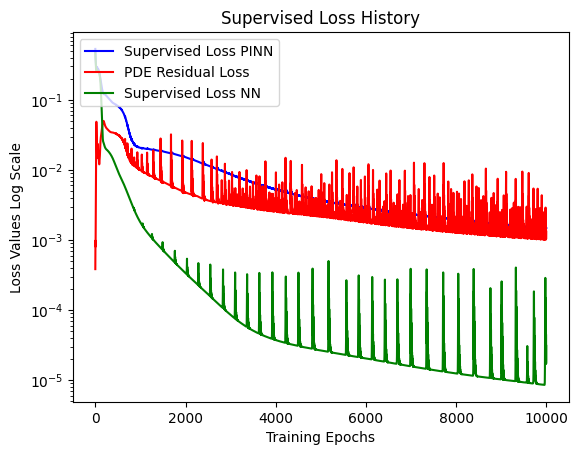

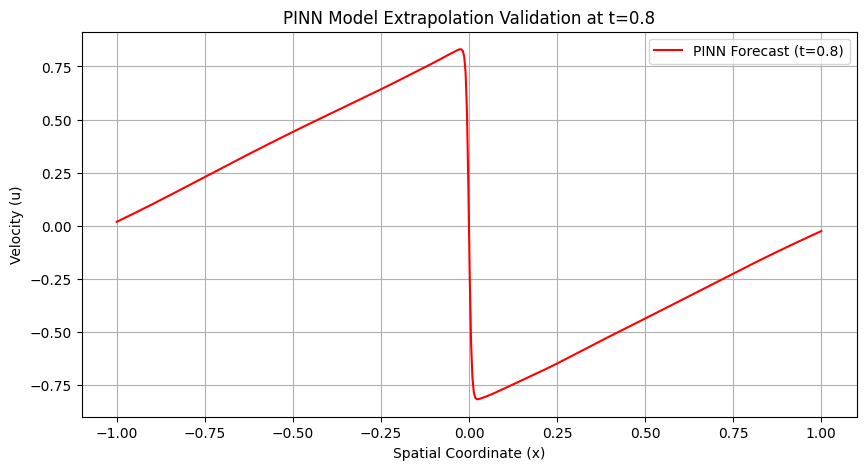

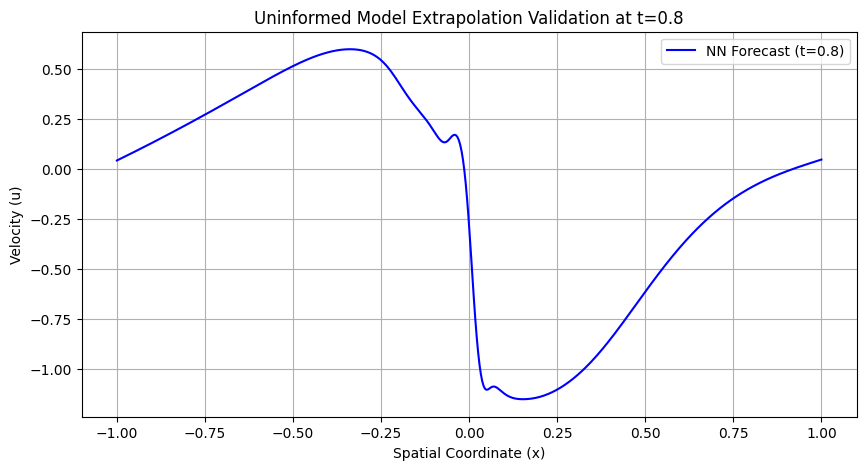

In [6]:
# Execute the pipeline
trained_model_pinn, trained_model_uninformed, history = train_pinn(epochs=10000, lr=1e-3, lambda_0 = 1., lambda_1=1., informed_model=model_pinn, uninformed_model=model_uninformed)
evaluate_model(trained_model_pinn, trained_model_uninformed, 512, history)

[[ 0.05947226]
 [ 0.07456395]
 [ 0.0902752 ]
 ...
 [-0.03835553]
 [-0.0336833 ]
 [-0.02905251]]
[[ 0.13311297]
 [ 0.14650011]
 [ 0.16019589]
 ...
 [-0.0432142 ]
 [-0.03893399]
 [-0.03470182]]


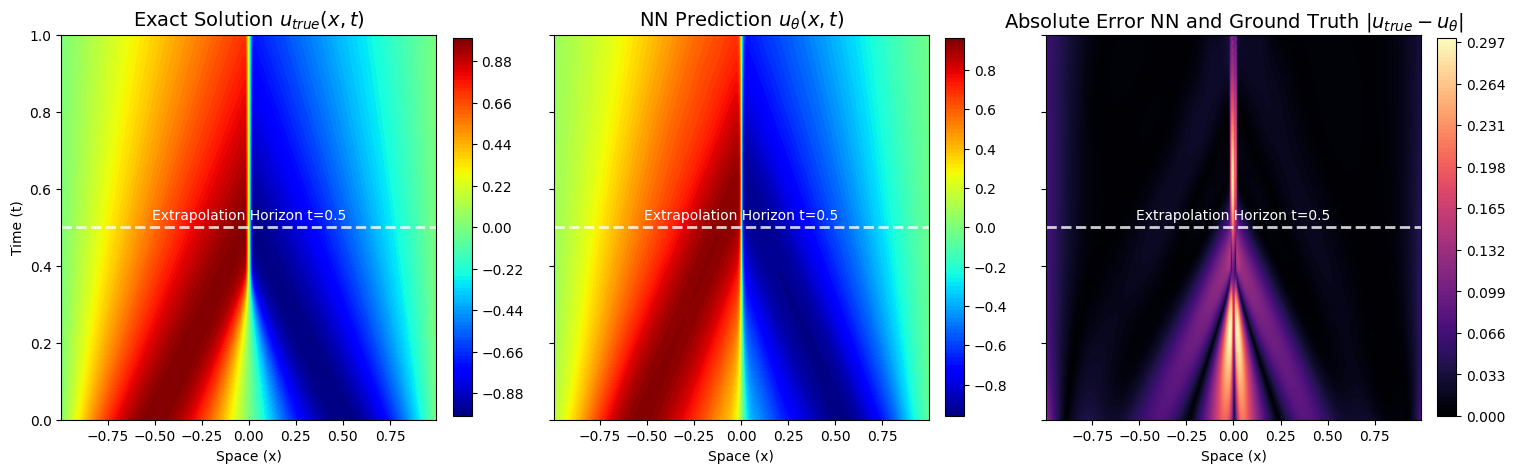

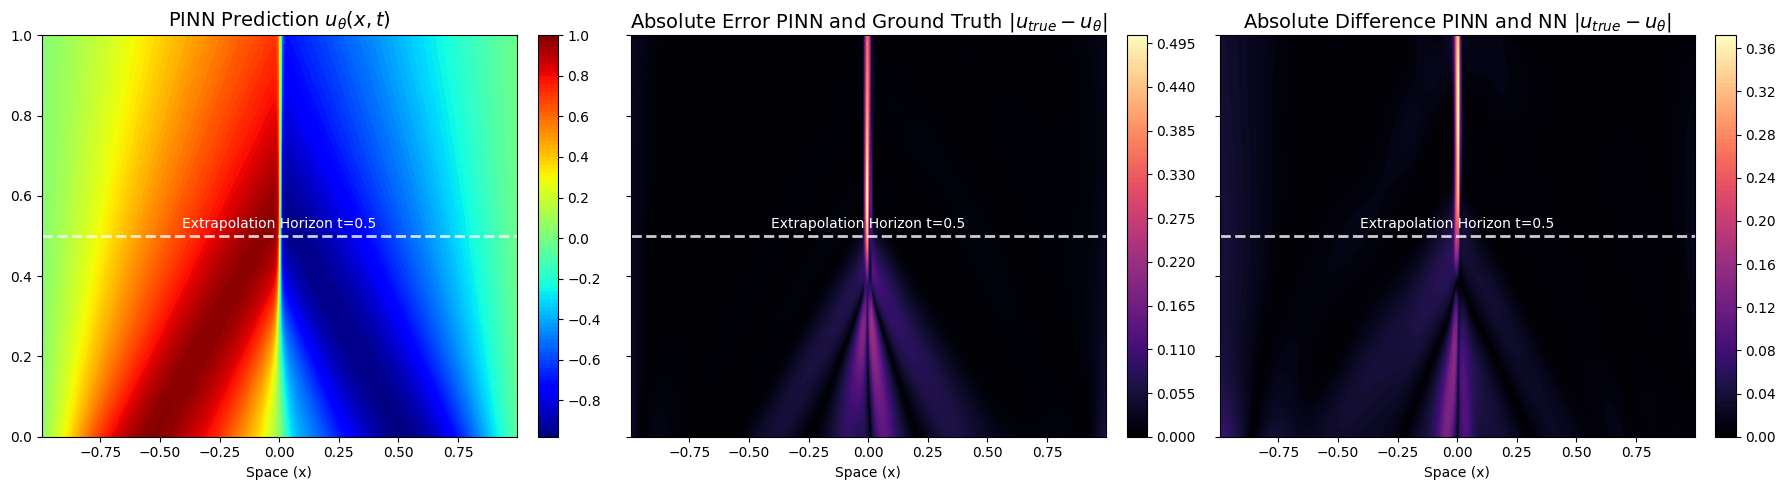

In [7]:
visualize_results(trained_model_pinn_path='pinn_model_weights_run_2026-03-12', trained_model_path='model_weights_run_2026-03-11', device=torch.device("mps"))

## KAN Pipeline

Replicating the training loop using the same data and evaluation methodology but using a KAN instead.

In [7]:
def physical_loss_KAN(model, x, t, nu):
    """
    Evaluates the Burgers' equation residual exactly as before.
    The continuous B-splines of the KAN support create_graph=True natively.
    """
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    # KAN models require concatenated inputs across the feature dimension
    inputs = torch.cat([x, t], dim=1)
    u = model(inputs)
    
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    residual = u_t + u * u_x - nu * u_xx
    return torch.mean(residual**2)

In [ ]:
def evaluate_kan(trained_kan_model, test_grid_size, history):
    # plot training history

    plt.figure()
    plt.plot(np.arange(len(history['data_loss'])), history['data_loss'], label = 'Supervised Loss PI-KAN', color = 'blue')
    plt.plot(np.arange(len(history['pde_loss'])), history['pde_loss'], label = 'PDE Residual Loss', color = 'red')
    plt.legend(loc = 'upper left')
    plt.title('Supervised Loss History')
    plt.ylabel('Loss Values Log Scale')
    plt.xlabel('Training Epochs')
    plt.yscale('log')
    
    plt.show()

    
    trained_kan_model.eval()
    model_uninformed.eval()
    
    
    # visual validation at "snapshot" t = 0.8, repeated for each network
    t_eval = 0.8
    device = torch.device("mps")
    test_x_vis = torch.linspace(-1, 1, test_grid_size).view(-1, 1).to(device)
    test_t_vis = torch.full((test_grid_size, 1), t_eval).to(device)
    kan_input = torch.cat([test_x_vis, test_t_vis], dim=1)
    
    with torch.no_grad():
        pred_vis = trained_kan_model(kan_input).cpu().numpy()
        
    plt.figure(figsize=(10, 5))
    plt.plot(test_x_vis.cpu().numpy(), pred_vis, label=f"PI-KAN Forecast (t={t_eval})", color="red")
    plt.title(f"PI-KAN Model Extrapolation Validation at t={t_eval}")
    plt.xlabel("Spatial Coordinate (x)")
    plt.ylabel("Velocity (u)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [55]:
def train_pi_kan():
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu"))
    print(f"Executing Physics-Informed Optimization on: {device}")
    
    nu_true = 0.01 / py_math.pi
    data_splits = prepare_data(t_split=0.5, spatial_mask_ratio=0.8)
    
    x_train, t_train, u_train = [t.to(device) for t in data_splits['train']]
    x_colloc, t_colloc = [t.to(device) for t in data_splits['colloc']]
    
    # Initialize the KAN
    # width=[2 inputs, 20 hidden, 20 hidden, 1 output]
    # grid=5 provides base spatial flexibility, k=3 ensures continuous second derivatives
    model_kan = KAN(width=[2, 20, 20, 1], grid=5, k=3).to(device)
    
    # We use Adam for the initial manifold descent
    optimizer = optim.Adam(model_kan.parameters(), lr=1e-3)
    
    epochs = 2000
    history = {'data_loss': [], 'pde_loss': []}

    model_kan.train()
    
    for epoch in range(epochs):

        optimizer.zero_grad()
        
        train_inputs = torch.cat([x_train, t_train], dim=1)
        u_pred = model_kan(train_inputs)
        loss_data = torch.nn.functional.mse_loss(u_pred, u_train)
    
        loss_pde = physical_loss_KAN(model_kan, x_colloc, t_colloc, nu=nu_true)
       
        loss_total = loss_data + loss_pde
        loss_total.backward()
        optimizer.step()
    
        history['data_loss'].append(loss_data.item())
        history['pde_loss'].append(loss_pde.item())
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Data Loss: {loss_data.item():.6e} | PDE Loss: {loss_pde.item():.6e}")

    torch.save(trained_kan.state_dict(), 'Models/trained_kan_weights_'+str(date.today()))
    return model_kan, data_splits, device, history

# Execute the KAN pipeline
trained_kan, splits, comp_device, kan_training_history = train_pi_kan()

Executing Physics-Informed Optimization on: mps
checkpoint directory created: ./model
saving model version 0.0
Epoch 0000 | Data Loss: 4.733948e-01 | PDE Loss: 2.980761e-04
Epoch 0500 | Data Loss: 3.414712e-02 | PDE Loss: 2.083896e-02
Epoch 1000 | Data Loss: 7.970231e-03 | PDE Loss: 9.624378e-03
Epoch 1500 | Data Loss: 6.562277e-03 | PDE Loss: 8.691044e-03


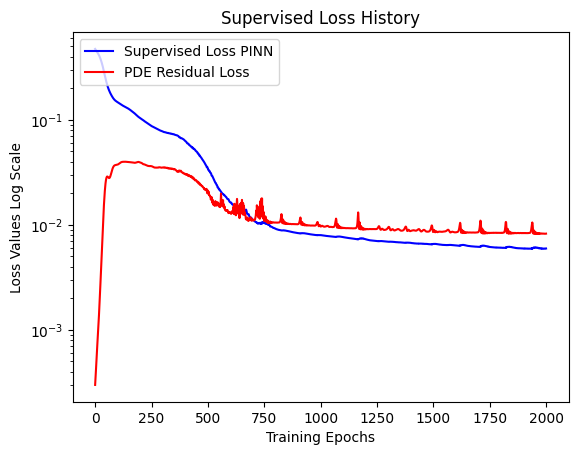

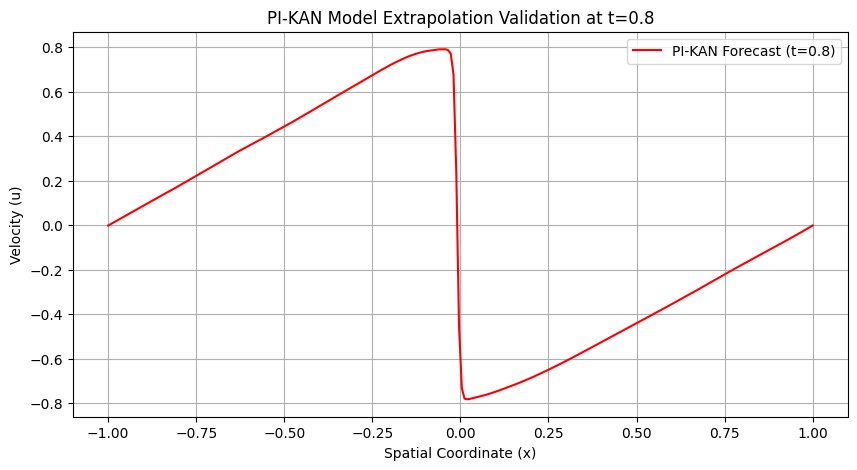

In [56]:
evaluate_kan(trained_kan, test_grid_size=256, history=kan_training_history)